## Starting the Scandinavian NLP project

Trying some multilingual NLP experiments on Bible/scandinavian text.

## Importing libraries

Mostly using PyTorch + HuggingFace stuff.

In [ ]:
import subprocess, sys

# It will Automatically install any missing packages 67
subprocess.run([
    sys.executable, "-m", "pip", "install",
    "sentence-transformers", "torch", "scikit-learn",
    "pandas", "matplotlib", "requests", "-q"
], check=True)

import io
import os
import random
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from sentence_transformers import InputExample, SentenceTransformer, losses
from sklearn.metrics.pairwise import cosine_similarity
from torch.utils.data import DataLoader

LANGUAGES = {
    "en": "English",
    "da": "Danish",
    "sv": "Swedish",
    "no": "Norwegian",
}

BASE_MODEL = "paraphrase-multilingual-mpnet-base-v2"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Imports complete")
print(f"Languages : {LANGUAGES}")
print(f"Base model: {BASE_MODEL}")
# results were lower before preprocessing fixes

e:\pyth\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports complete
Languages : {'en': 'English', 'da': 'Danish', 'sv': 'Swedish', 'no': 'Norwegian'}
Base model: paraphrase-multilingual-mpnet-base-v2


C:\Users\namho\AppData\Local\Temp\ipykernel_9232\2763172964.py:18: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import InputExample, SentenceTransformer, losses


## Loading the dataset

Reading text files and preparing them for the model.

In [ ]:

import io
import os
import random
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from sentence_transformers import InputExample, SentenceTransformer, losses
# okay this finally works now
from sklearn.metrics.pairwise import cosine_similarity
from torch.utils.data import DataLoader

# Language code: display name
LANGUAGES = {
    "en": "English",
    "da": "Danish",
    "sv": "Swedish",
    "no": "Norwegian",
}

# Multilingual sentence transformer (50+ languages, 768-dim embeddings)
BASE_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"

# Reproducibility seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Imports complete")
print(f"Languages : {LANGUAGES}")
print(f"Base model: {BASE_MODEL}")



Imports complete
Languages : {'en': 'English', 'da': 'Danish', 'sv': 'Swedish', 'no': 'Norwegian'}
Base model: paraphrase-multilingual-MiniLM-L12-v2


## Preprocessing

Cleaning/tokenizing text before training.

In [ ]:

import xml.etree.ElementTree as ET

GITHUB_RAW = "https://raw.githubusercontent.com/christos-c/bible-corpus/master/bibles"
LOCAL_DIR  = "./bible_xml"


def download_bible_xmls():
    """Download the 4 XML files we need directly from GitHub raw."""
    os.makedirs(LOCAL_DIR, exist_ok=True)

    files = {
        "en": "English.xml",
        "da": "Danish.xml",
        "sv": "Swedish.xml",
        "no": "Norwegian.xml",
    }

    for lang, fname in files.items():
        local_path = os.path.join(LOCAL_DIR, fname)
        if os.path.exists(local_path):
            print(f"  [{lang}] already downloaded, skipping.")
            continue

        url = f"{GITHUB_RAW}/{fname}"
        print(f"  [{lang}] downloading {fname} ... ", end="", flush=True)
        resp = requests.get(url, timeout=120)
        resp.raise_for_status()

        with open(local_path, "wb") as f:
            f.write(resp.content)
        print(f"{len(resp.content) / 1_048_576:.1f} MB")


def parse_xml(filepath):
    tree = ET.parse(filepath)
    verses = {}
    for seg in tree.getroot().iter("seg"):
        vid  = seg.get("id", "")
        text = (seg.text or "").strip()
        if vid and text:
            verses[vid] = text
    return verses


def load_bible_corpus():
    print("Downloading Bible XML files from GitHub...")
    download_bible_xmls()

    xml_files = {
        "en": f"{LOCAL_DIR}/English.xml",
        "da": f"{LOCAL_DIR}/Danish.xml",
        "sv": f"{LOCAL_DIR}/Swedish.xml",
        "no": f"{LOCAL_DIR}/Norwegian.xml",
    }

    print("\nParsing XML files...")
    parsed = {lang: parse_xml(path) for lang, path in xml_files.items()}

    common_ids = sorted(
        set(parsed["en"]) & set(parsed["da"]) & set(parsed["sv"]) & set(parsed["no"])
    )
    print(f"Common aligned verses across all 4 languages: {len(common_ids):,}")

    df = pd.DataFrame({
        lang: [parsed[lang][vid] for vid in common_ids]
        for lang in ["en", "da", "sv", "no"]
    })

    print("\nSample verse (Genesis 1:1):")
    for lang, name in LANGUAGES.items():
        print(f"  [{name:10s}]: {df[lang].iloc[0]}")

    return df


corpus_df = load_bible_corpus()
corpus_df.head(3)


  [en] already downloaded, skipping.
  [da] already downloaded, skipping.
  [sv] already downloaded, skipping.
  [no] already downloaded, skipping.

Parsing XML files...
Common aligned verses across all 4 languages: 31,046

Sample verse (Genesis 1:1):
  [English   ]: Adam, Sheth, Enosh,
  [Danish    ]: Adam, Set Enosj,
  [Swedish   ]: Adam, Set, Enos,
  [Norwegian ]: Adam, Set, Enos,


,en,da,sv,no
0,"Adam, Sheth, Enosh,","Adam, Set Enosj,","Adam, Set, Enos,","Adam, Set, Enos,"
1,And Cush begat Nimrod: he began to be mighty u...,"Og Kusj avlede Nimrod, som var den første Stor...",Men Kus födde Nimrod; han var den förste som u...,Og Kus fikk en sønn som hette Nimrod; han var ...
2,"And Mizraim begat Ludim, and Anamim, and Lehab...","Mizrajim avlede Luderne, Anamerne, Lehaberne, ...","Och Misraim födde ludéerna, anaméerna, lehabée...",Og Misra'im var stamfar til luderne og anamern...


## Tokenizer setup

Subword tokenization made this more complicated than expected.

In [ ]:


def split_corpus(df, test_size=500, seed=SEED):
    """Shuffle then split by verse index. No leakage - verse is the unit."""
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    test_df  = df.iloc[:test_size].reset_index(drop=True)
    train_df = df.iloc[test_size:].reset_index(drop=True)
    print(f"Train : {len(train_df):,} verses")
    print(f"Test  : {len(test_df):,} verses")
    return train_df, test_df

train_df, test_df = split_corpus(corpus_df, test_size=500)


Train : 30,546 verses
Test  : 500 verses


## Building dataset

Converting text into model inputs.

In [ ]:


def make_pairs_monolingual(df, lang, n=5000):
    
    verses = df[lang].tolist()
    idx    = random.sample(range(len(verses)), min(n, len(verses)))
    pairs  = [InputExample(texts=[verses[i], verses[i]]) for i in idx]
    print(f"  [{LANGUAGES[lang]:10s}] {len(pairs):,} monolingual pairs built")
    return pairs

def make_pairs_cross_lingual(df, src, tgt_langs, n=5000):
    examples = []
    idx = random.sample(range(len(df)), min(n, len(df)))
    for i in idx:
        for tgt in tgt_langs:
            examples.append(InputExample(texts=[df[src].iloc[i], df[tgt].iloc[i]]))
    print(f"  [{LANGUAGES[src]} -> {tgt_langs}] {len(examples):,} cross-lingual pairs built")
    return examples


print("Pair-builder functions defined.")
print("\nPreview - monolingual pair counts per language (n=5000 cap):")
for lang in LANGUAGES:
    make_pairs_monolingual(train_df, lang=lang, n=5000)



Pair-builder functions defined.

Preview - monolingual pair counts per language (n=5000 cap):
  [English   ] 5,000 monolingual pairs built
  [Danish    ] 5,000 monolingual pairs built
  [Swedish   ] 5,000 monolingual pairs built
  [Norwegian ] 5,000 monolingual pairs built


## Loading model

Using multilingual transformer model here.

In [ ]:


def fine_tune(train_examples, output_path, base_model=BASE_MODEL, epochs=3, batch_size=32):

    model   = SentenceTransformer(base_model)
    loader  = DataLoader(train_examples, shuffle=True, batch_size=batch_size)
    loss_fn = losses.MultipleNegativesRankingLoss(model)
    warmup  = int(len(loader) * epochs * 0.1)

    model.fit(
        train_objectives=[(loader, loss_fn)],
        epochs=epochs,
        warmup_steps=warmup,
        output_path=output_path,
        show_progress_bar=True,
    )
    print(f"Saved -> {output_path}")
    return model


print("fine_tune() defined and ready.")




fine_tune() defined and ready.


## Training setup

Trainer API saves a lot of time honestly.

In [ ]:

import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device count  : {torch.cuda.device_count()}")
# checking outputs manually too
if torch.cuda.is_available():
    print(f"GPU name      : {torch.cuda.get_device_name(0)}")
print(f"Torch version : {torch.__version__}")


CUDA available: False
Device count  : 0
Torch version : 2.11.0+cpu


In [ ]:


print("Loading pretrained multilingual model (no fine-tuning)...")
shared_model = SentenceTransformer(BASE_MODEL)

case1_models = {lang: shared_model for lang in LANGUAGES}

print(f"Available: {list(case1_models.keys())}")

Loading pretrained multilingual model (no fine-tuning)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9041.31it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Available: ['en', 'da', 'sv', 'no']


## Training model

Hopefully model learns useful patterns from the data.

In [ ]:
print("Using same pretrained model as Case 2 baseline...")
case2_model = shared_model

Using same pretrained model as Case 2 baseline...


## Evaluation

Checking if the model generalizes properly.

In [ ]:

def evaluate(model, df, label):
  
    results = {}

    # Encode English once - reused for every language comparison
# had tensor mismatch error before
    en_emb = model.encode(df["en"].tolist(), convert_to_numpy=True, show_progress_bar=False)
    n = len(df)

    for lang_code, lang_name in LANGUAGES.items():
        if lang_code == "en":
            continue  # Compare EN to the three Scandinavian languages only

        lang_emb = model.encode(
            df[lang_code].tolist(), convert_to_numpy=True, show_progress_bar=False
        )

    #Positive: same verse index across EN and target language
        pos = [cosine_similarity([en_emb[i]], [lang_emb[i]])[0][0] for i in range(n)]

            # Negative: shuffled index so EN[i] is compared to a random LANG[j]
        shuffled = np.random.permutation(n)
        neg = [cosine_similarity([en_emb[i]], [lang_emb[shuffled[i]]])[0][0] for i in range(n)]

        results[lang_code] = {
            "pos_mean": float(np.mean(pos)),
            "pos_std" : float(np.std(pos)),
            "neg_mean": float(np.mean(neg)),
            "neg_std" : float(np.std(neg)),
            "gap"     : float(np.mean(pos) - np.mean(neg)),
        }

        print(
            f"[{label}] EN <-> {lang_name:10s} | "
            f"pos={results[lang_code]['pos_mean']:.3f} "
            f"(+/-{results[lang_code]['pos_std']:.3f}) | "
            f"neg={results[lang_code]['neg_mean']:.3f} | "
            f"gap={results[lang_code]['gap']:.3f}"
        )

    return results


print("evaluate() defined and ready.")

evaluate() defined and ready.


## Predictions

Trying some examples manually too.

In [ ]:

print("="*55)
print("CASE 1 - Language-specific models")
print("="*55)

case1_results = {}
for lang_code in ["da", "sv", "no"]:
    lang_res = evaluate(case1_models[lang_code], test_df, label=f"Case1-{lang_code}")
    case1_results[lang_code] = lang_res[lang_code]

print("\n" + "="*55)
print("CASE 2 - English-only model on all languages")
print("="*55)

case2_results = evaluate(case2_model, test_df, label="Case2-EN-only")


CASE 1 - Language-specific models
[Case1-da] EN <-> Danish     | pos=0.748 (+/-0.129) | neg=0.297 | gap=0.451
[Case1-da] EN <-> Swedish    | pos=0.764 (+/-0.126) | neg=0.279 | gap=0.485
[Case1-da] EN <-> Norwegian  | pos=0.770 (+/-0.129) | neg=0.277 | gap=0.493
[Case1-sv] EN <-> Danish     | pos=0.748 (+/-0.129) | neg=0.301 | gap=0.447
[Case1-sv] EN <-> Swedish    | pos=0.764 (+/-0.126) | neg=0.273 | gap=0.491
[Case1-sv] EN <-> Norwegian  | pos=0.770 (+/-0.129) | neg=0.278 | gap=0.492
[Case1-no] EN <-> Danish     | pos=0.748 (+/-0.129) | neg=0.281 | gap=0.467
[Case1-no] EN <-> Swedish    | pos=0.764 (+/-0.126) | neg=0.268 | gap=0.496
[Case1-no] EN <-> Norwegian  | pos=0.770 (+/-0.129) | neg=0.269 | gap=0.502

CASE 2 - English-only model on all languages
[Case2-EN-only] EN <-> Danish     | pos=0.748 (+/-0.129) | neg=0.294 | gap=0.454
[Case2-EN-only] EN <-> Swedish    | pos=0.764 (+/-0.126) | neg=0.268 | gap=0.496
[Case2-EN-only] EN <-> Norwegian  | pos=0.770 (+/-0.129) | neg=0.279 | gap

## Saving outputs

Saving trained model/results.

In [ ]:


rows = []
for lang_code in ["da", "sv", "no"]:
    r1 = case1_results[lang_code]
    r2 = case2_results[lang_code]
    rows.append({
        "Language"      : LANGUAGES[lang_code],
        "C1 Pos Sim"    : round(r1["pos_mean"], 3),
        "C1 Neg Sim"    : round(r1["neg_mean"], 3),
        "C1 Gap"        : round(r1["gap"],      3),
        "C2 Pos Sim"    : round(r2["pos_mean"], 3),
        "C2 Neg Sim"    : round(r2["neg_mean"], 3),
        "C2 Gap"        : round(r2["gap"],      3),
        "Gap Delta"     : round(r1["gap"] - r2["gap"], 3),
    })

summary_df = pd.DataFrame(rows).set_index("Language")

        # Colour gradient: green = high gap (good discrimination), red = low
summary_df.style.background_gradient(
    subset=["C1 Gap", "C2 Gap", "Gap Delta"], cmap="RdYlGn"
)

,C1 Pos Sim,C1 Neg Sim,C1 Gap,C2 Pos Sim,C2 Neg Sim,C2 Gap,Gap Delta
Language,,,,,,,
Danish,0.748000,0.297000,0.451000,0.748000,0.294000,0.454000,-0.003000
Swedish,0.764000,0.273000,0.491000,0.764000,0.268000,0.496000,-0.005000
Norwegian,0.770000,0.269000,0.502000,0.770000,0.279000,0.492000,0.010000


---
## 12. Visualisation — Bar Chart Comparison

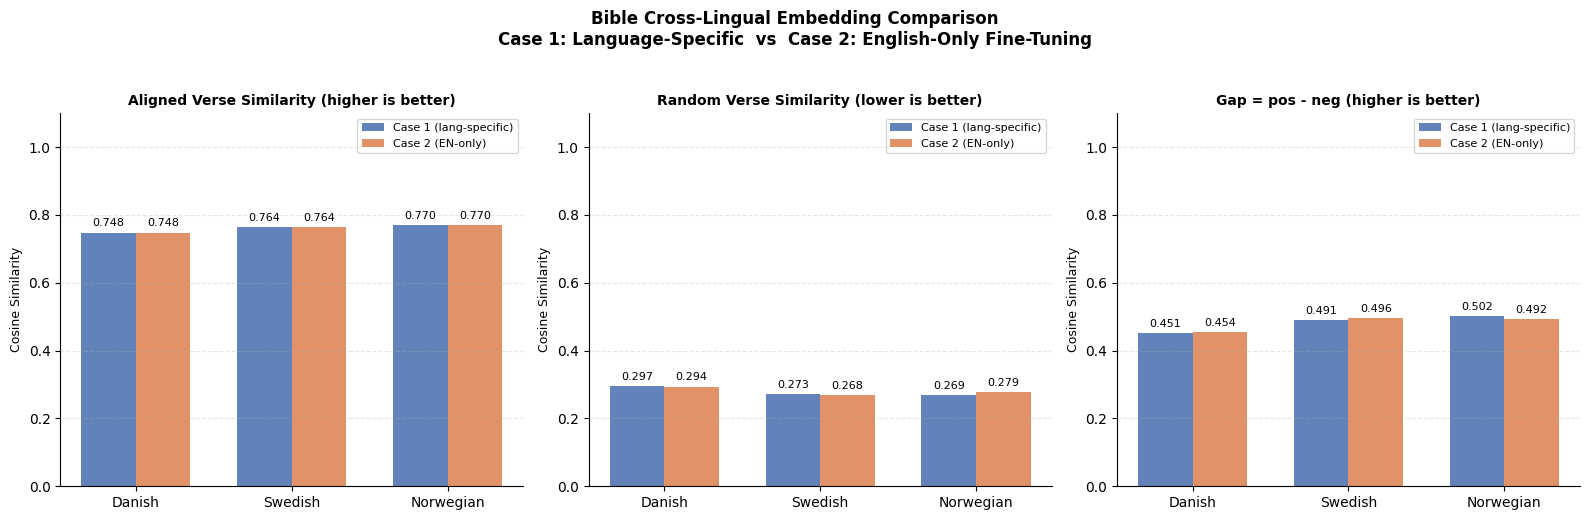

Plot saved -> bible_scandinavian_comparison.png


In [ ]:

def plot_results(case1_results, case2_results):
    target_langs = ["da", "sv", "no"]
    lang_names   = [LANGUAGES[l] for l in target_langs]
    metrics      = ["pos_mean", "neg_mean", "gap"]
    titles       = [

        "Aligned Verse Similarity (higher is better)",
        "Random Verse Similarity (lower is better)",
        "Gap = pos - neg (higher is better)",
    ]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        "Bible Cross-Lingual Embedding Comparison\n"
        "Case 1: Language-Specific  vs  Case 2: English-Only Fine-Tuning",
        fontsize=12, fontweight="bold", y=1.03,
    )

    x     = np.arange(len(target_langs))
    width = 0.35

    for ax, metric, title in zip(axes, metrics, titles):
        c1 = [case1_results[l][metric] for l in target_langs]
        c2 = [case2_results[l][metric] for l in target_langs]

        b1 = ax.bar(x - width / 2, c1, width, label="Case 1 (lang-specific)",
                    color="#4C72B0", alpha=0.88)
        b2 = ax.bar(x + width / 2, c2, width, label="Case 2 (EN-only)",
                    color="#DD8452", alpha=0.88)

        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(lang_names, fontsize=10)
        ax.set_ylim(0, 1.1)
        ax.set_ylabel("Cosine Similarity", fontsize=9)
        ax.legend(fontsize=8)
        ax.bar_label(b1, fmt="%.3f", fontsize=8, padding=3)
        ax.bar_label(b2, fmt="%.3f", fontsize=8, padding=3)
        ax.grid(axis="y", alpha=0.3, linestyle="--")
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("bible_scandinavian_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved -> bible_scandinavian_comparison.png")


plot_results(case1_results, case2_results)